In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\user\Desktop\data\togo-dapaong_qc.csv")

In [2]:
df.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [3]:
#list any column with >5% nulls.

null_percent = df.isnull().mean() * 100
cols_with_nulls = null_percent[null_percent > 5]
print(cols_with_nulls)

Comments    100.0
dtype: float64


In [4]:
#Outlier detection using IQR
columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

outliers = {}
for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))
    outliers[col] = df[col][outlier_mask].count()
        

#Check for Incorrect entries (negative values for irradiance and wind speed)
invalid_values = {}
for col in ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']:
    invalid_values[col] = (df[col] < 0).sum()

# Print results
print("Outliers Detected in Dataset 1:\n", outliers, "\n")
print("Physically Incorrect Entries (Negatives):\n", invalid_values)


Outliers Detected in Dataset 1:
 {'GHI': np.int64(1303), 'DNI': np.int64(50586), 'DHI': np.int64(7905), 'ModA': np.int64(1237), 'ModB': np.int64(1537), 'WS': np.int64(8708), 'WSgust': np.int64(7377)} 

Physically Incorrect Entries (Negatives):
 {'GHI': np.int64(257385), 'DNI': np.int64(0), 'DHI': np.int64(0), 'ModA': np.int64(0), 'ModB': np.int64(0), 'WS': np.int64(0), 'WSgust': np.int64(0)}


In [5]:
# Columns for Z-score computation
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

means = df[cols].mean()
stds = df[cols].std(ddof=0)  # ddof=0 uses population standard deviation

z_scores = (df[cols] - means) / stds

outlier_rows = (z_scores.abs() > 3).any(axis=1)
flagged_outliers = df[outlier_rows]

print(f"Number of flagged outlier rows: {flagged_outliers.shape[0]}")

Number of flagged outlier rows: 9251


In [6]:
#Handle negative values

invalid_columns = ['GHI', 'DNI', 'DHI']

def clean_negative_values(df):
    for col in invalid_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].mask(df[col] < 0)
        df[col] = df[col].fillna(df[col].dropna().median())
    return df

df = clean_negative_values(df)

print(df.min())

Timestamp        2021-10-25 00:01
GHI                           0.0
DNI                           0.0
DHI                           0.0
ModA                          0.0
ModB                          0.0
Tamb                         14.9
RH                            3.3
WS                            0.0
WSgust                        0.0
WSstdev                       0.0
WD                            0.0
WDstdev                       0.0
BP                            968
Cleaning                        0
Precipitation                 0.0
TModA                        13.1
TModB                        13.1
Comments                      NaN
dtype: object


In [7]:
# # Handle the outliers entries

irradiance_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

df = cap_outliers(df, irradiance_cols)


C:\Users\user\AppData\Local\Temp\ipykernel_2328\3438317190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set3')


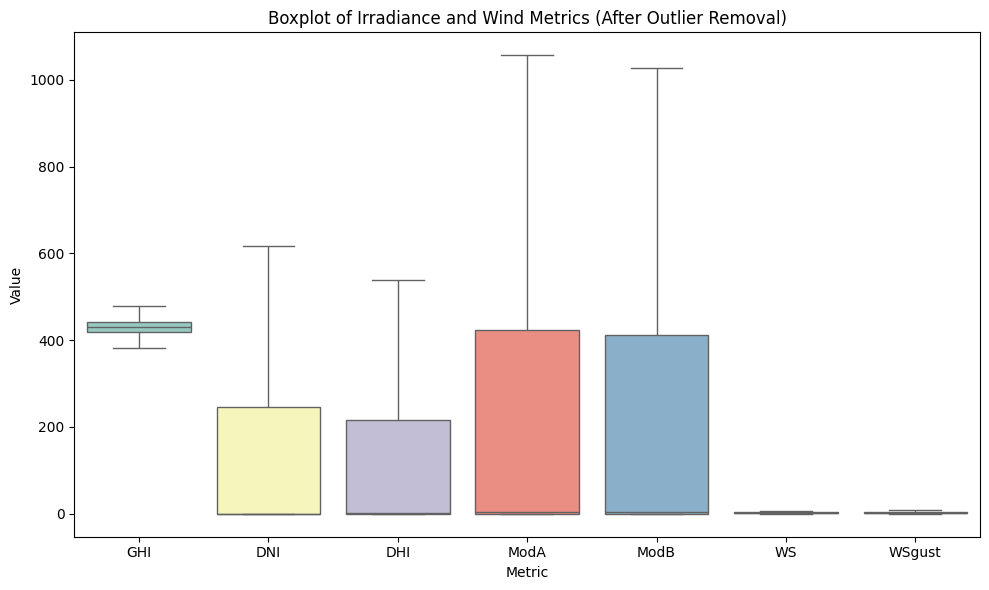

In [8]:
#check the outliers
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = df[irradiance_cols].melt(var_name='Metric', value_name='Value')

# Plot boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set3')
plt.title('Boxplot of Irradiance and Wind Metrics (After Outlier Removal)')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [9]:
import os

country = "Togo"  

os.makedirs('data', exist_ok=True)

output_path = f'data/{country}_clean.csv'
df.to_csv(output_path, index=False)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


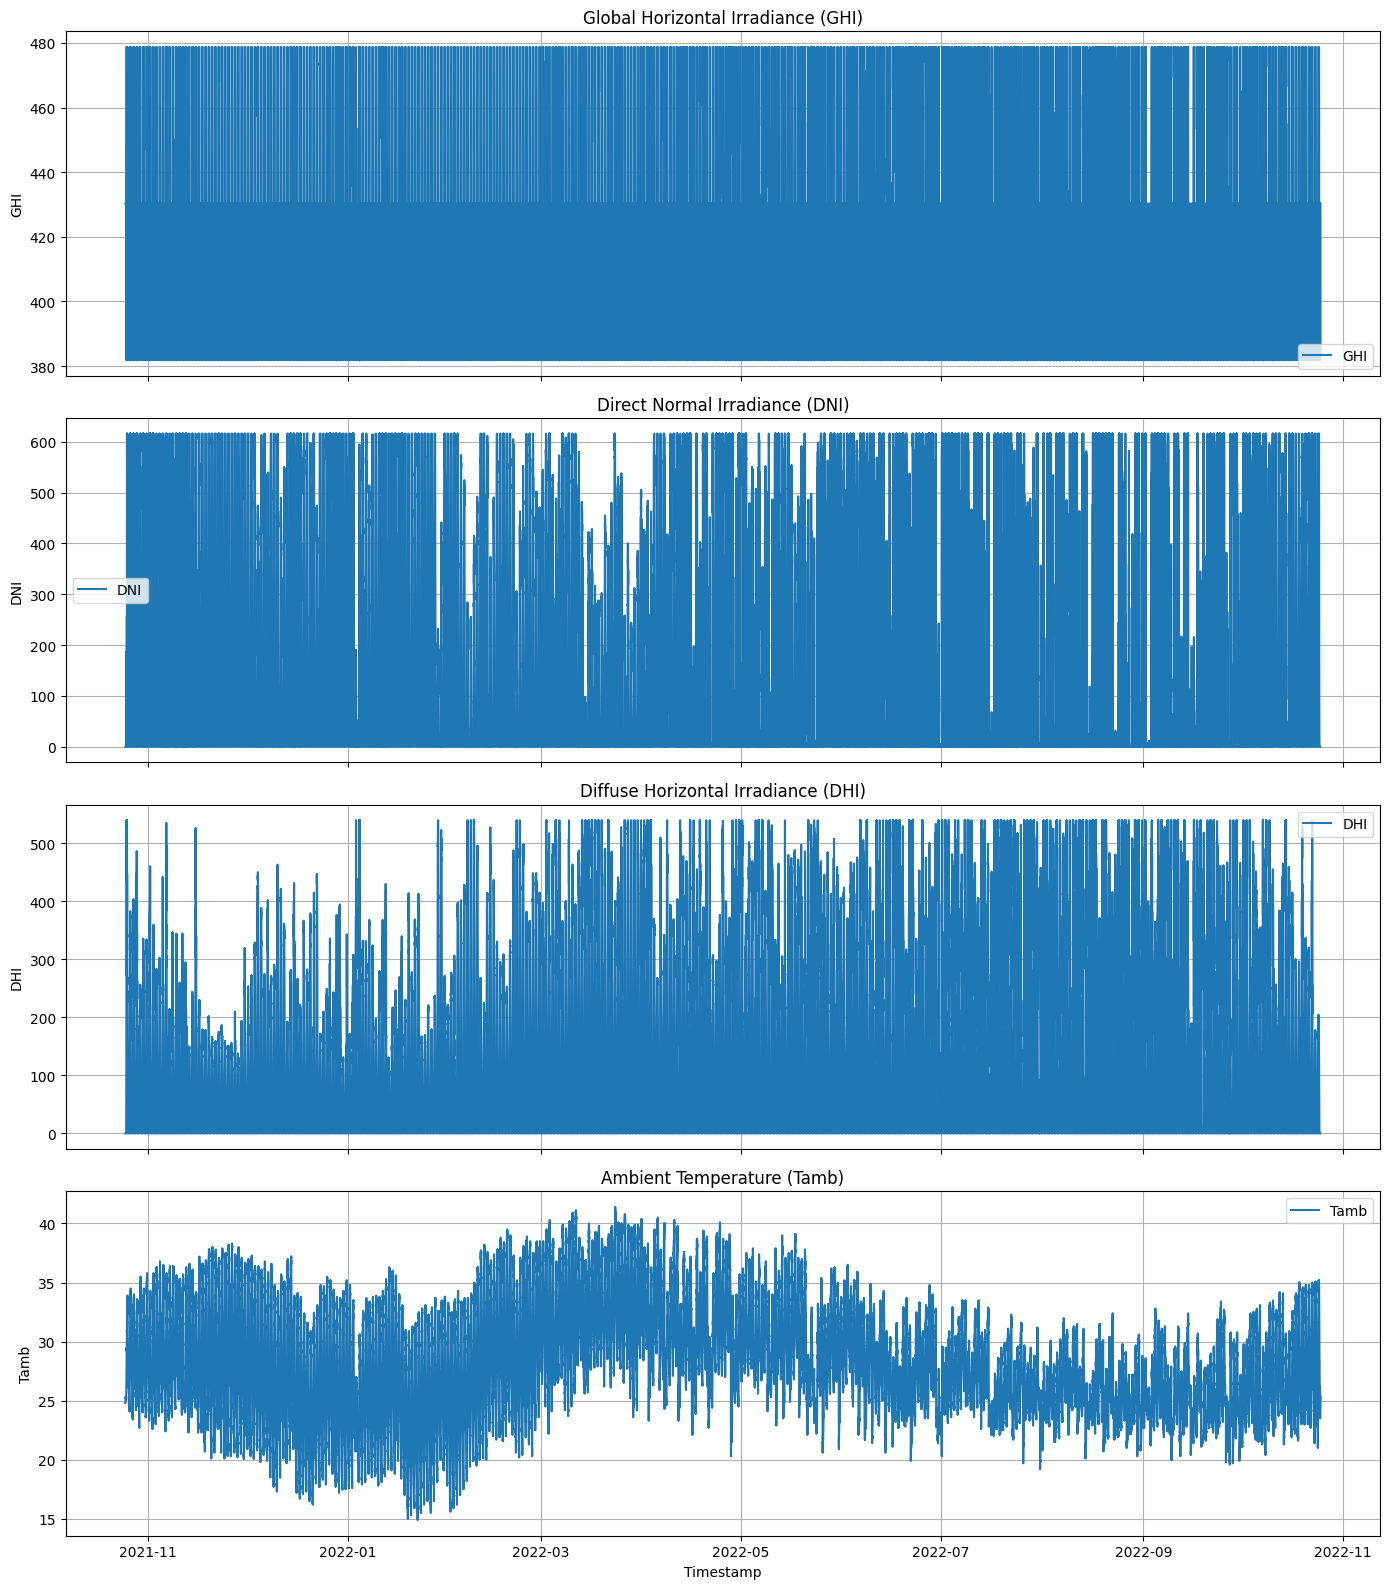

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv(r"../data/Togo_clean.csv")

df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], format='%Y-%m-%d %H:%M', errors='raise')

fig, axs = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

cols_to_plot = ['GHI', 'DNI', 'DHI', 'Tamb']
titles = ['Global Horizontal Irradiance (GHI)', 'Direct Normal Irradiance (DNI)', 
          'Diffuse Horizontal Irradiance (DHI)', 'Ambient Temperature (Tamb)']

for i, col in enumerate(cols_to_plot):
    axs[i].plot(df1['Timestamp'], df1[col], label=col, color='tab:blue')
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(col)
    axs[i].legend()
    axs[i].grid(True)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()


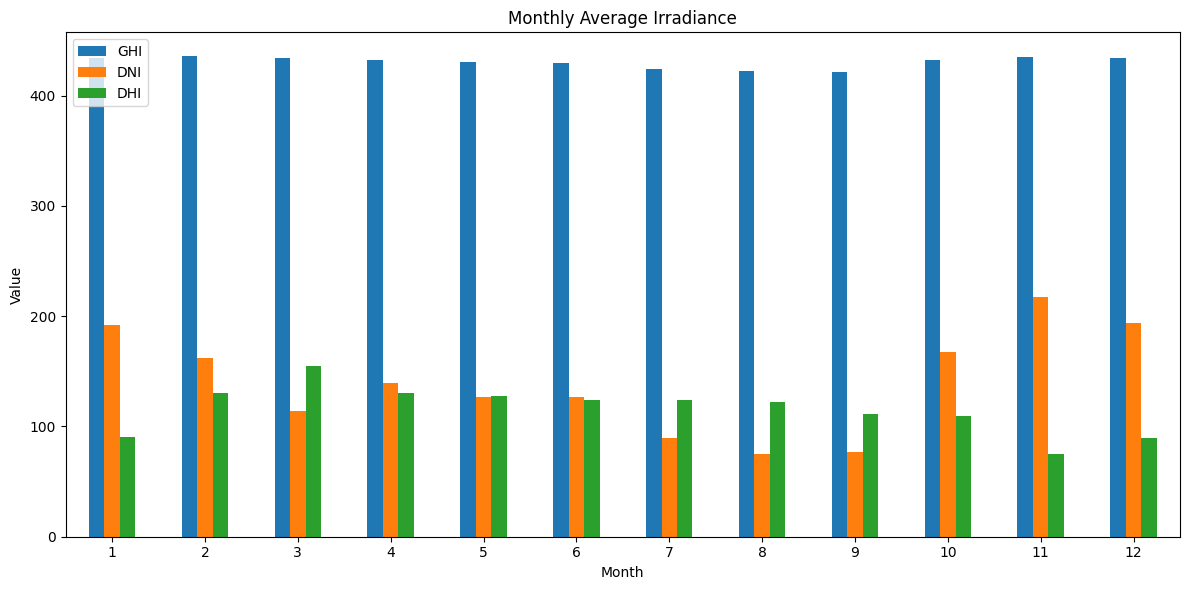

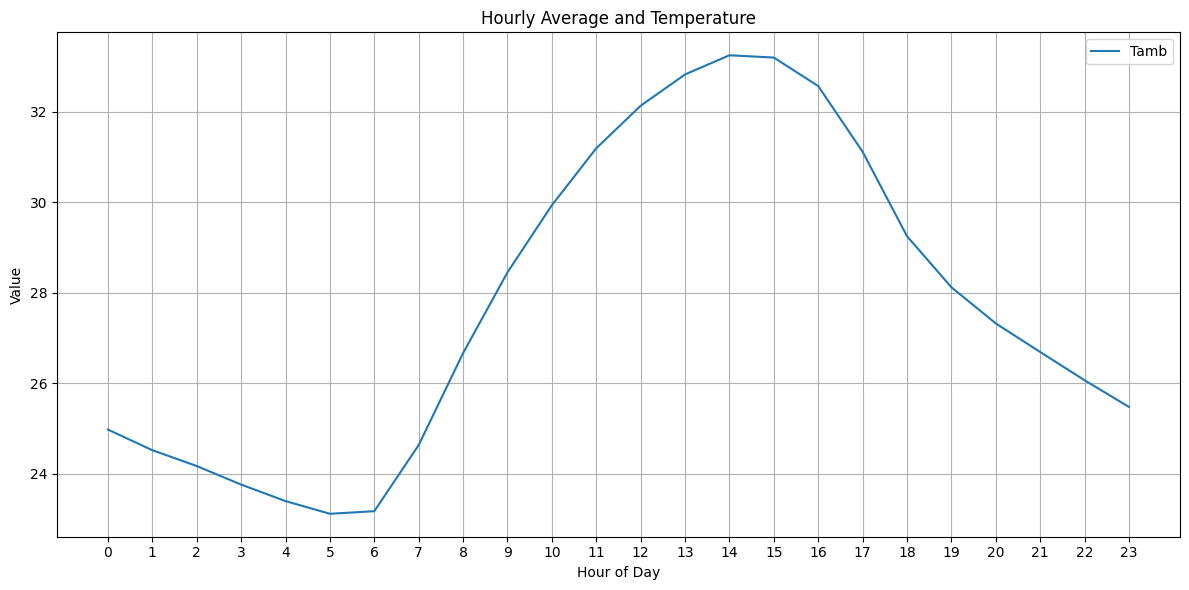

Anomaly Summary:
                 Timestamp       GHI  Tamb
167837 2022-02-18 13:18:00  478.7375  38.9
167838 2022-02-18 13:19:00  478.7375  39.0
167839 2022-02-18 13:20:00  478.7375  39.0
167840 2022-02-18 13:21:00  478.7375  39.0
167841 2022-02-18 13:22:00  478.7375  39.0


In [11]:
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], format='%Y-%m-%d %H:%M', errors='raise')

df1['Month'] = df1['Timestamp'].dt.month
df1['Hour'] = df1['Timestamp'].dt.hour

# 1. Monthly Averages (Seasonal Trends)

monthly_avg = df1.groupby('Month')[['GHI', 'DNI', 'DHI']].mean()

monthly_avg.plot(kind='bar', figsize=(12, 6))
plt.title('Monthly Average Irradiance')
plt.ylabel('Value')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 2. Hourly Averages (Daily Cycle Trends)

hourly_avg = df1.groupby('Hour')[['Tamb']].mean()

hourly_avg.plot(figsize=(12, 6))
plt.title('Hourly Average and Temperature')
plt.ylabel('Value')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Anomaly Detection (Irradiance Peaks & Temp Spikes)

ghi_threshold = df1['GHI'].quantile(0.99)
tamb_threshold = df1['Tamb'].quantile(0.99)

anomalies = df1[(df1['GHI'] > ghi_threshold) | (df1['Tamb'] > tamb_threshold)]

print("Anomaly Summary:")
print(anomalies[['Timestamp', 'GHI', 'Tamb']].sort_values(by='Timestamp').head())


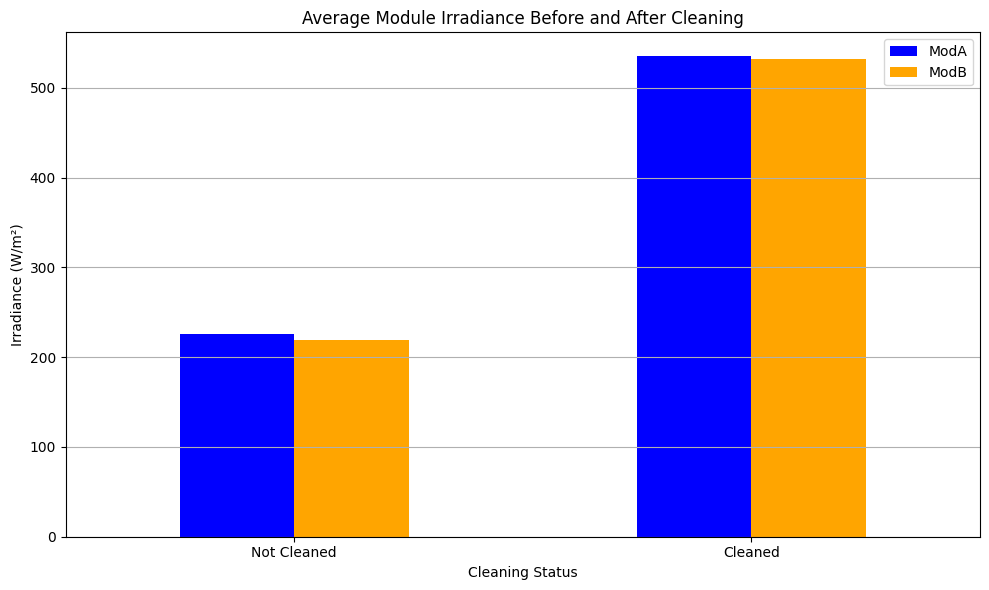

In [12]:
cleaning_group = df1.groupby('Cleaning')[['ModA', 'ModB']].mean().rename(index={0: 'Not Cleaned', 1: 'Cleaned'})

cleaning_group.plot(kind='bar', figsize=(10,6), color=['blue', 'orange'])
plt.title('Average Module Irradiance Before and After Cleaning')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Cleaning Status')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

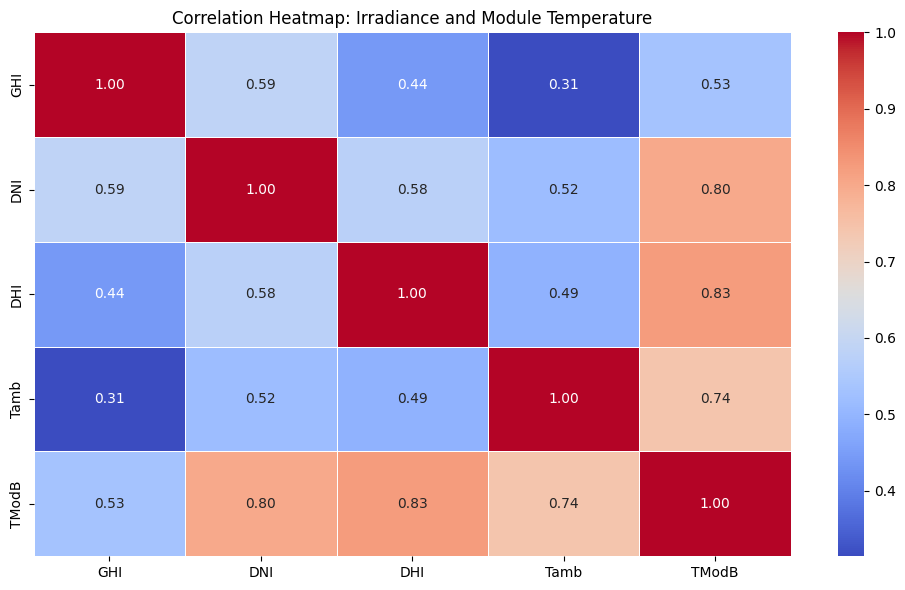

In [13]:
import seaborn as sns
corr_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'TModB']
corr_matrix =  df1[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Irradiance and Module Temperature')
plt.tight_layout()
plt.show()

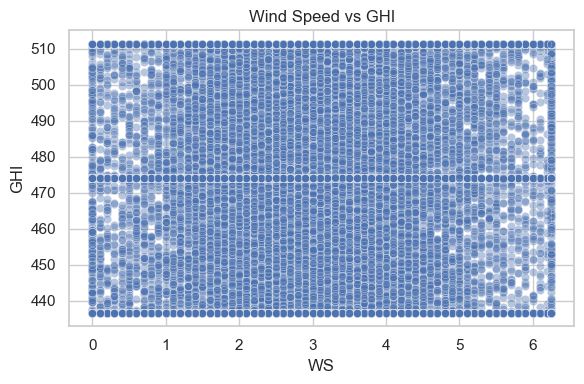

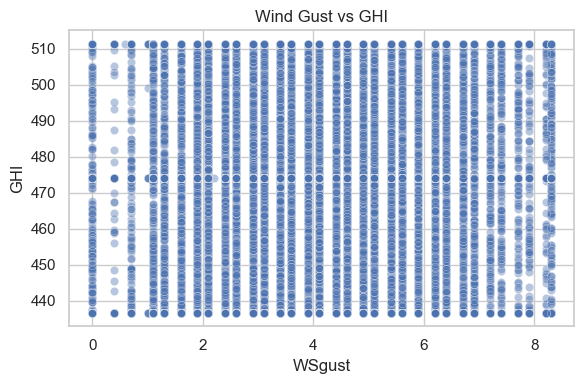

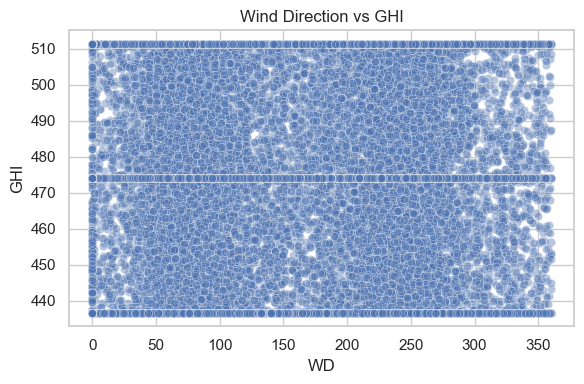

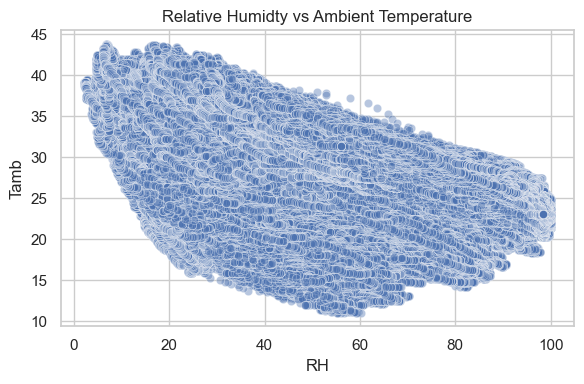

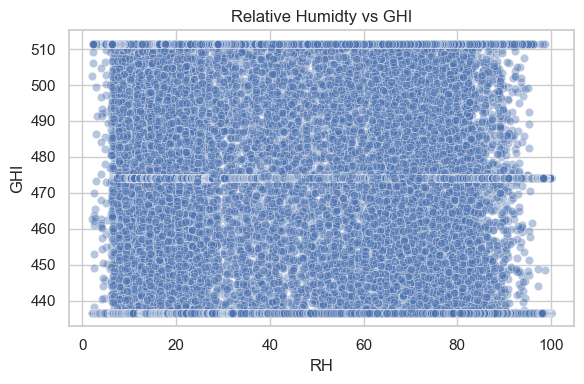

In [43]:
sns.set(style='whitegrid')

#Plot 1
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='WS', y='GHI', alpha=0.4)
plt.title('Wind Speed vs GHI')
plt.tight_layout()
plt.show()

#Plot 2
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='WSgust', y='GHI', alpha=0.4)
plt.title('Wind Gust vs GHI')
plt.tight_layout()
plt.show()

#Plot 3
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='WD', y='GHI', alpha=0.4)
plt.title('Wind Direction vs GHI')
plt.tight_layout()
plt.show()

#Plot 4
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='RH', y='Tamb', alpha=0.4)
plt.title('Relative Humidty vs Ambient Temperature')
plt.tight_layout()
plt.show()

#Plot 5
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='RH', y='GHI', alpha=0.4)
plt.title('Relative Humidty vs GHI')
plt.tight_layout()
plt.show()

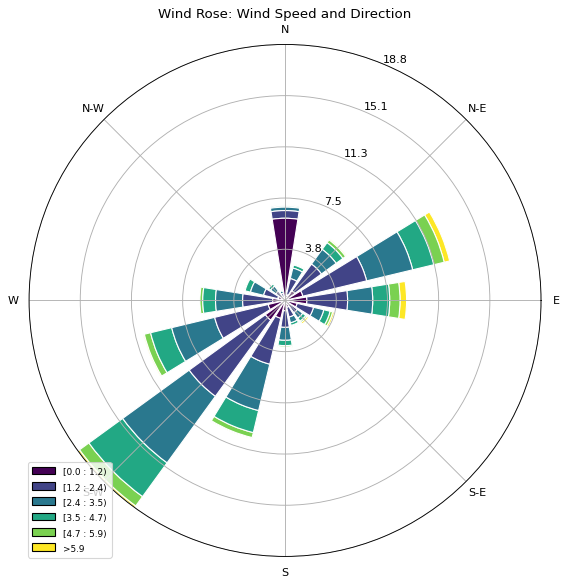

In [14]:
from windrose import WindroseAxes

wind_data = df1[['WS', 'WD']]

ax = WindroseAxes.from_ax()
ax.bar(wind_data['WD'], wind_data['WS'], normed=True, opening=0.8, edgecolor='white', cmap=None)
ax.set_legend()
plt.title('Wind Rose: Wind Speed and Direction')
plt.show()

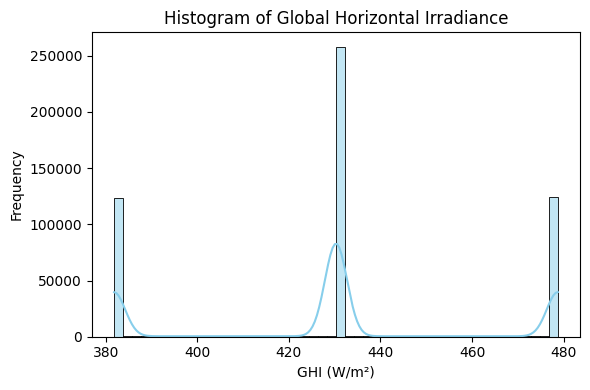

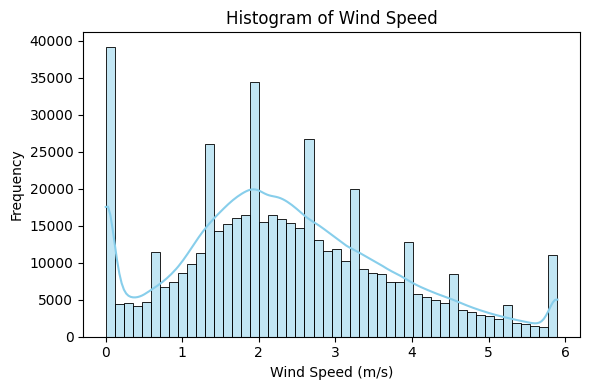

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df1['GHI'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Global Horizontal Irradiance')
plt.xlabel('GHI (W/m²)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(df1['WS'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [16]:
rh_corr_tamb = df1['RH'].corr(df1['Tamb'])
print(f"Correlation between RH and Tamb: {rh_corr_tamb:.2f}")


Correlation between RH and Tamb: -0.40


C:\Users\user\AppData\Local\Temp\ipykernel_2328\3700554428.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rh_bin_summary = df1.groupby('RH_bin')[['Tamb', 'GHI']].mean()


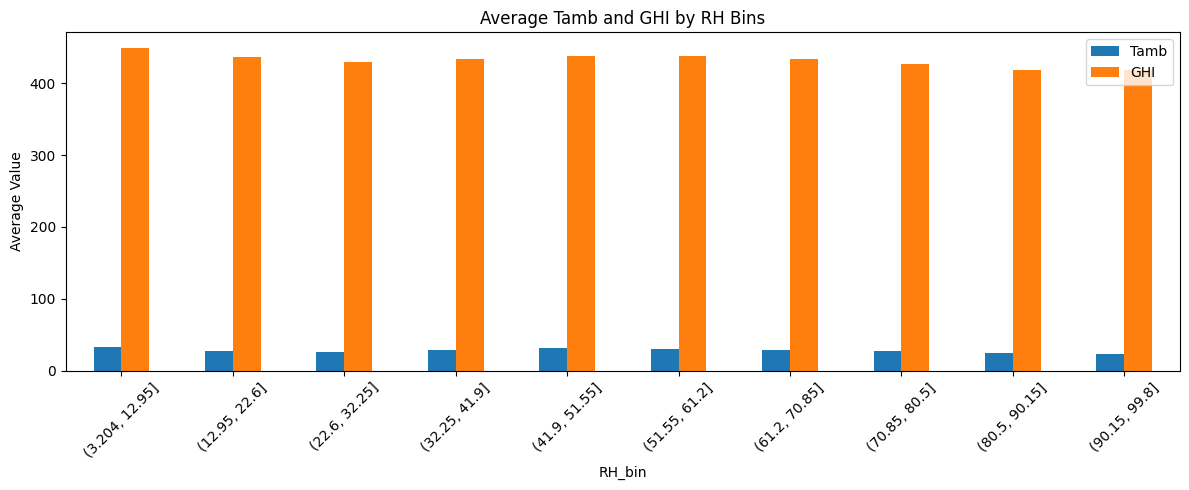

Correlation between RH and Tamb: -0.40
Correlation between RH and Tamb: -0.22


In [17]:
#How relative humidity (RH) might influence temperature readings and solar radiation.
df1['RH_bin'] = pd.cut(df1['RH'], bins=10)

rh_bin_summary = df1.groupby('RH_bin')[['Tamb', 'GHI']].mean()

rh_bin_summary.plot(kind='bar', figsize=(12, 5))
plt.title('Average Tamb and GHI by RH Bins')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rh_corr_tamb = df1['RH'].corr(df1['Tamb'])
rh_corr_ghi = df1['RH'].corr(df1['GHI'])

print(f"Correlation between RH and Tamb: {rh_corr_tamb:.2f}")
print(f"Correlation between RH and Tamb: {rh_corr_ghi:.2f}")


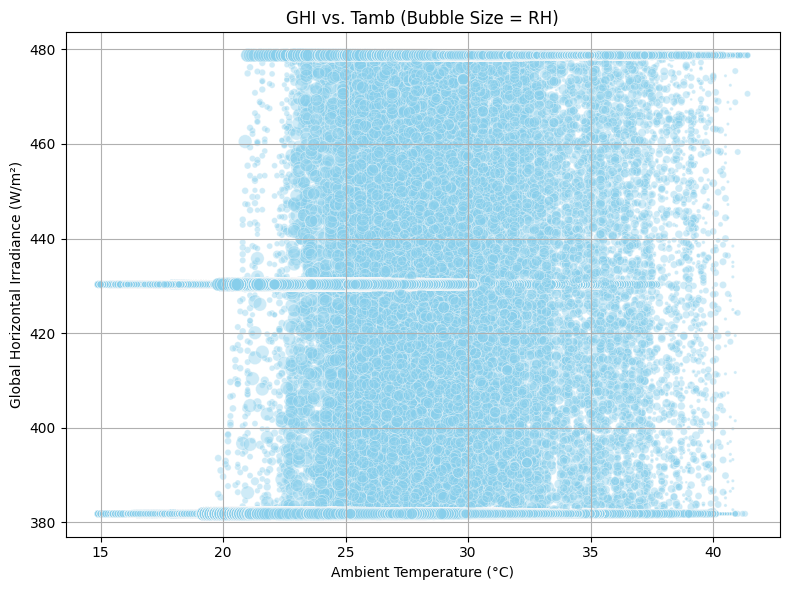

In [18]:
#Bubble Chart

plt.figure(figsize=(8, 6))
plt.scatter(df1['Tamb'], df1['GHI'], s=df1['RH'], alpha=0.4, c='skyblue', edgecolors='w', linewidth=0.5)
plt.title('GHI vs. Tamb (Bubble Size = RH)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True)
plt.tight_layout()
plt.show()
